In [ ]:
# import json
# import pandas as pd

# with open("chatbot_results.json", "r", encoding="utf-8") as f:
#     data = json.load(f)

# df = pd.DataFrame(data)

# # df["interactions"] = df["interactions"].apply(json.loads)
# df = pd.concat([df.drop(columns=["interactions"]), df["interactions"].apply(pd.Series)], axis=1)
# #df["longueur_reponse"] = df["interaction", "response"].apply(lambda x: len(str(x)))

# #df["longueur_reponse"] = df["response"].apply(lambda x: len(str(x)))
# df_scores=pd.DataFrame(columns=["faithfulness_score", "relevance_score", "coherence_score", "overall_score"])
# faithfulness_scores = [0.07, 0.08, 0.09, 0.1, 0.11]
# relevance_scores = [0.8, 0.85, 0.9, 0.95, 1.0]
# coherence_scores = [0.6, 0.65, 0.7, 0.75, 0.8]
# overall_scores = [0.5, 0.55, 0.6, 0.65, 0.7]


# #print(df.head())
# print(df_scores.head())
# #from scripts.simulate_evaluation import simulate_evaluation, Evaluation, Interaction, RetrievedDocument
# #Interaction.query("longueur_reponse > 1000")


#mon token github :

Empty DataFrame
Columns: [faithfulness_score, relevance_score, coherence_score, overall_score]
Index: []


In [16]:
import sys
import os

project_root = r"C:\Users\loubr\Documents\Scolarite\Stage_AnelAI\rag-evaluation-monitoring-system-for-regulatory-develop"
src_path = os.path.join(project_root, "src")

sys.path.append(src_path)

import rems
rems.__file__

'C:\\Users\\loubr\\Documents\\Scolarite\\Stage_AnelAI\\rag-evaluation-monitoring-system-for-regulatory-develop\\src\\rems\\__init__.py'

In [1]:
import pandas as pd
import json
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
import sklearn
from lightgbm import LGBMRegressor
import lightgbm as lgb
import joblib
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture



In [ ]:
#docs.giskard.ai : https://legacy-docs.giskard.ai/en/stable/open_source/testset_generation/testset_generation/index.html

In [2]:

classe=["hallucination","hallucination","acceptable","hallucination","acceptable","low_quality","acceptable","acceptable","acceptable","acceptable","acceptable","acceptable","retrieval_failure","retrieval_failure","acceptable","retrieval_failure","acceptable","retrieval_failure","acceptable","retrieval_failure","retrieval_failure","hallucination","hallucination","acceptable","acceptable","acceptable","acceptable","retrieval_failure","acceptable","low_quality","acceptable","acceptable","acceptable","retrieval_failure","retrieval_failure","retrieval_failure","hallucination","low_quality","acceptable","low_quality","acceptable","retrieval_failure","hallucination","off_topic","hallucination","acceptable","retrieval_failure","low_quality","retrieval_failure","retrieval_failure","acceptable","acceptable","retrieval_failure","acceptable","retrieval_failure"]


In [3]:

with open("chatbot_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df_data = pd.DataFrame(data)
df_data = pd.concat([df_data.drop(columns=["interactions"]), df_data["interactions"].apply(pd.Series)], axis=1)
#df_data["interactions"] = df_data["interactions"].apply(json.loads)


def longueur_reponse_utile(texte: str) -> int:
    """
    Retourne la longueur de la partie utile d'une réponse,
    en coupant tout ce qui vient après le premier '\n\n\n'.
    """

    if "*Références" in texte:
        texte_utile = texte.split("*Références")[0]
    else:
        texte_utile = texte  # si jamais il n'y a pas de partie inutile

    # 2) On nettoie les espaces superflus
    texte_utile = texte_utile.strip()

    # 3) On retourne la longueur
    return len(texte_utile)


df = pd.read_csv("evaluation.csv")
df["longueur_reponse"] = df_data["response"].apply(lambda x: longueur_reponse_utile(str(x)))
df["longueur_query"]=df_data["query"].apply(lambda x : len(str(x)))
df["nb_documents_retrieves"]=df_data["retrieved_documents"].apply(lambda x : len(x) if isinstance(x, list) else 0)
df["label_qualite"]=classe
mapping = {"acceptable": 0, "hallucination": 1, "retrieval_failure": 2, "low_quality": 3, "off_topic": 4}
df["label_qualite"]=df["label_qualite"].map(mapping)

#print(df.head())
#print(df_data.head())
print(df["longueur_reponse"][df["longueur_reponse"]==min(df["longueur_reponse"])])
print(len(df))
print(len(df_data))
print(df.head())

score_generation=(df["faithfulness"]+df["answer_relevancy"])/2
overall_score=0.35*df["retrieval_score"]+0.65*score_generation

#print(f"score generation: {score_generation}, overall score: {overall_score}")
#print(len(df_data["retrieved_documents"][0]))
#df["longueur_reponse"] = df_data["response"].apply(lambda x: len(str(x)))

33    38
52    38
Name: longueur_reponse, dtype: int64
55
55
   faithfulness  retrieval_score  answer_relevancy  context_precision  \
0           1.0            0.855             0.846              0.710   
1           1.0            0.817             0.780              0.633   
2           0.5            1.000             0.812              1.000   
3           1.0            1.000             0.827              1.000   
4           1.0            1.000             0.721              1.000   

   longueur_reponse  longueur_query  nb_documents_retrieves  label_qualite  
0               674              45                       6              1  
1               694              35                       6              1  
2               360              60                       5              0  
3               474              52                       5              1  
4               172              37                       5              0  


In [ ]:
col=["faithfulness","answer_relevancy","context_precision","retrieval_score","longueur_reponse","longueur_query","nb_documents_retrieves"]
print(df[col].head())

   faithfulness  answer_relevancy  context_precision  retrieval_score  \
0           1.0             0.846              0.710            0.855   
1           1.0             0.780              0.633            0.817   
2           0.5             0.812              1.000            1.000   
3           1.0             0.827              1.000            1.000   
4           1.0             0.721              1.000            1.000   

   longueur_reponse  longueur_query  nb_documents_retrieves  
0               674              45                       6  
1               694              35                       6  
2               360              60                       5  
3               474              52                       5  
4               172              37                       5  


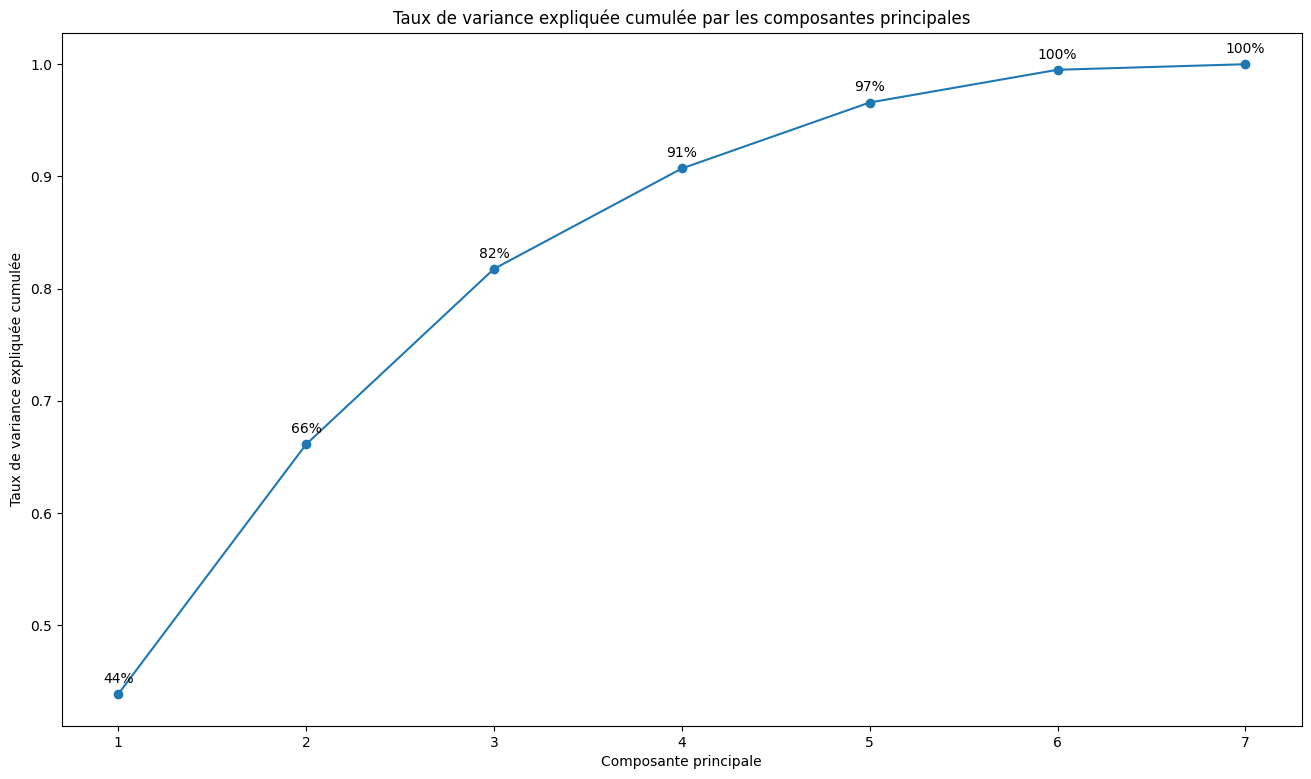

In [4]:
pca = PCA()
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(df.drop("label_qualite",axis=1)),
    columns=df.drop("label_qualite",axis=1).columns
)
pca.fit(X)
features_pca = pca.transform(X)

cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(16, 9)) # ouvre une figure de proportions 16/9

x_values = range(1, pca.n_components_ + 1)
plt.plot(x_values, cumsum, "o-")
for i, var_ratio in zip(x_values, cumsum):
    plt.text(i, var_ratio + 0.01, f"{var_ratio:.0%}", ha="center")
plt.xlabel("Composante principale")
plt.ylabel("Taux de variance expliquée cumulée")
plt.title("Taux de variance expliquée cumulée par les composantes principales")
plt.show()

répartition des labels: 
acceptable           25
retrieval_failure    16
hallucination         8
low_quality           5
off_topic             1
Name: count, dtype: int64


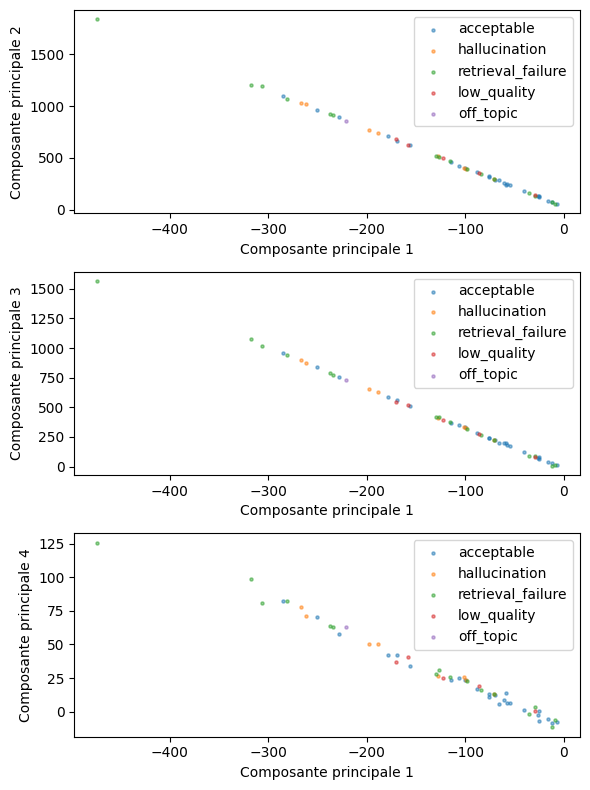

In [5]:
pca = PCA()
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)
pca.fit(X)
features_pca = pca.transform(X)

labels_values={0: "acceptable", 1: "hallucination", 2: "retrieval_failure", 3: "low_quality", 4: "off_topic"}
labels=pd.Categorical(df["label_qualite"],[0,1,2,3,4],ordered=True)

labels = labels.rename_categories(labels_values)
labels=pd.Series(labels)
print(f"répartition des labels: \n{labels.value_counts()}")
# print(df.head())


component_couples = (0, 1), (0, 2), (0, 3)
fig, axes = plt.subplots(3, 1, figsize=(6, 8))
for components, ax in zip(component_couples, axes):
    # on sépare les features selon les modalités des labels:
    for label, group in df.groupby(labels, observed=True):
        # on projette les features sur les composantes principales demandées:
        X_pca = pca.transform(group)
        features_2d = X_pca[:, components]

        ax.scatter(
            features_2d[:, 0], features_2d[:, 1],
            label=label,
            alpha=0.5,
            s=5,
        )
    
    ax.set_xlabel(f"Composante principale {components[0] + 1}")
    ax.set_ylabel(f"Composante principale {components[1] + 1}")
    # ax.set_title(pe
    #     f"Projection des données sur les composantes principales "
    #     f"{components[0] + 1} et {components[1] + 1}"
    # )
    ax.legend()
fig.tight_layout()
plt.show()

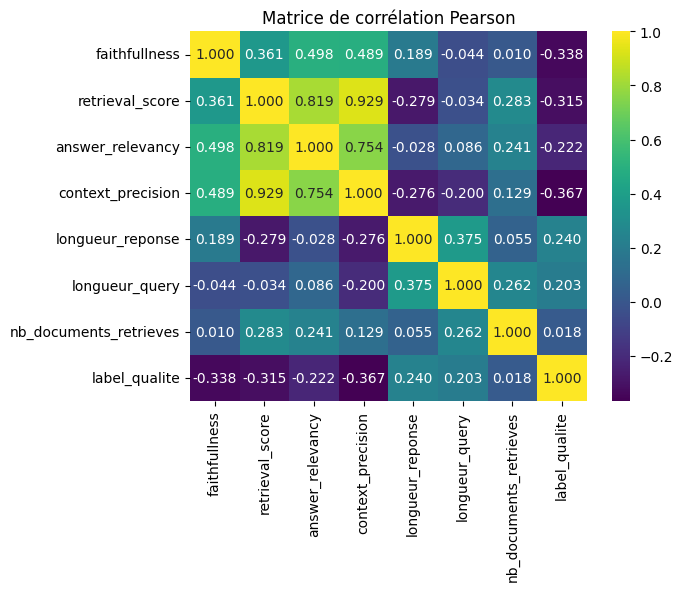

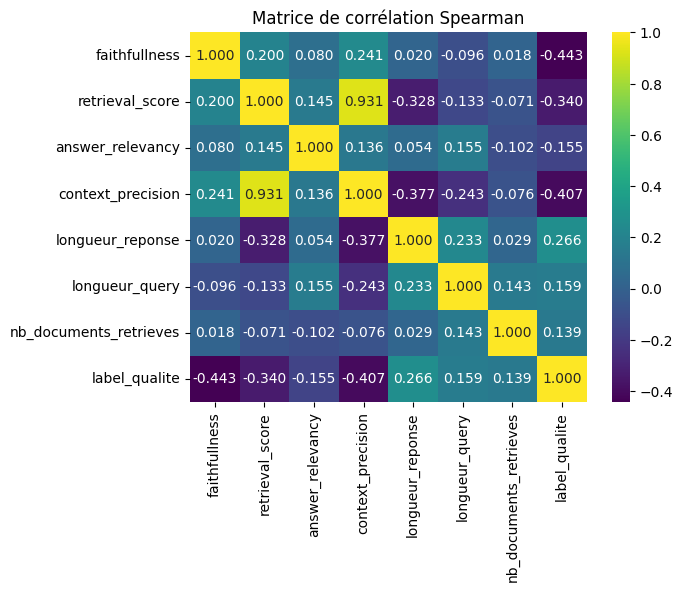

In [6]:
corr_pearson = df.corr(method="pearson")
corr_spearman=df.corr(method="spearman")

sns.heatmap(corr_pearson, annot=True, cmap="viridis", fmt=".3f")
plt.title("Matrice de corrélation Pearson")
plt.show()

sns.heatmap(corr_spearman,annot=True, cmap="viridis",fmt=".3f")
plt.title("Matrice de corrélation Spearman")
plt.show()

In [5]:
data_train, data_test = train_test_split(df ,test_size=0.3,    random_state=42)

xtrain = data_train.drop("label_qualite", axis=1)
ytrain = data_train["label_qualite"]
xtest = data_test.drop("label_qualite", axis=1)
ytest = data_test["label_qualite"]

model_rf=model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(xtrain, ytrain)

xgb_model=xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,     
    max_depth=6,            
    n_estimators=100,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='gbtree',    
    tree_method='auto',    
    scale_pos_weight=1     
)
model_xgb=xgb.XGBClassifier(random_state=42)
model_xgb.fit(xtrain, ytrain)

model_svm_ovo = svm.SVC(decision_function_shape='ovo', random_state=42)
model_svm_ovo.fit(xtrain, ytrain)

model_svm_linear = sklearn.svm.LinearSVC(C=1e9)
model_svm_linear.fit(xtrain, ytrain)
clf=svm.SVC(kernel='linear',gamma=1e9, random_state=42)
clf.fit(xtrain, ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1000000000.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
print(xtrain.columns)

Index(['faithfulness', 'retrieval_score', 'answer_relevancy',
       'context_precision', 'longueur_reponse', 'longueur_query',
       'nb_documents_retrieves'],
      dtype='object')


In [6]:
y_pred_rf = model_rf.predict(xtest)
y_pred_xgb = model_xgb.predict(xtest)
y_pred_svm_ovo = model_svm_ovo.predict(xtest)
y_pred_clf = clf.predict(xtest)


accuracy_rf = accuracy_score(ytest, y_pred_rf)
accuracy_xgb = accuracy_score(ytest, y_pred_xgb)
accuracy_svm_ovo = accuracy_score(ytest, y_pred_svm_ovo)
accuracy_clf = accuracy_score(ytest, y_pred_clf)


print(f"Accuracy Random Forest: {accuracy_rf*100:.2f}%")
print(f"Accuracy XGBoost: {accuracy_xgb*100:.2f}%")
print(f"Accuracy SVM OVO: {accuracy_svm_ovo*100:.2f}%")
print(f"Accuracy SVM Linear: {accuracy_clf*100:.2f}%")

Accuracy Random Forest: 47.06%
Accuracy XGBoost: 47.06%
Accuracy SVM OVO: 29.41%
Accuracy SVM Linear: 47.06%


In [9]:
#joblib.dump(model_rf, "model_rf_v1.joblib")
model_rf_loaded = joblib.load("diagnostic/model_rf_v1.joblib")
y_pred_rf_loaded = model_rf_loaded.predict(xtest)

qualite= xtest.copy()
qualite=qualite.assign(prediction=y_pred_rf_loaded)
print(qualite.head())
print(y_pred_rf_loaded)

    faithfulness  retrieval_score  answer_relevancy  context_precision  \
31         1.000            1.000             0.886              1.000   
5          0.933            1.000             0.803              1.000   
32         1.000            0.875             0.669              1.000   
13         1.000            0.874             0.737              0.747   
19         0.857            0.667             0.832              0.333   

    longueur_reponse  longueur_query  nb_documents_retrieves  prediction  
31                98              52                       6           0  
5               1067              63                       6           0  
32                47              39                      10           0  
13              1614              72                       7           1  
19               859              79                       5           2  
[0 0 0 1 2 1 1 2 2 1 2 0 2 2 0 0 0]


# Régression

In [10]:
data_reg=df.copy()
data_reg.pop("label_qualite")

import re

def nb_mots(query: str) -> float:
    mots = re.findall(r"\w+", query)
    nb_mots = len(mots)
    return round(nb_mots)

nb_entités=[1,1,2,1,1,2,1,1,1,1,1,0,1,0,0,1,0,0,0,0,0,1,1,1,0,1,0,1,1,1,1,1,1,2,1,1,2,2,1,2,1,1,1,0,0,0,2,2,2,1,2,1,2,1,0]
print(len(nb_entités))
data_reg["complexite_query"]= nb_entités/df_data["query"].apply(lambda x : nb_mots(x))
print(data_reg["complexite_query"].head())

55
0    0.100000
1    0.166667
2    0.285714
3    0.166667
4    0.142857
Name: complexite_query, dtype: float64


# Régression Faithfullness

In [ ]:


# data_train, data_test = train_test_split(data_reg ,test_size=0.2,    random_state=42)
# x_train=data_train.drop("faithfulness", axis=1)
# x_test=data_test.drop("faithfulness", axis=1)
# y_train=data_train["faithfulness"]
# y_test=data_test["faithfulness"]

# # pour le XGB
# dtrain = xgb.DMatrix(x_train,label=y_train) #,weight=weights)
# dtest = xgb.DMatrix(x_test, label=y_test)

# #pour le LGBM
# lgb_train = lgb.Dataset(x_train, label=y_train)
# lgb_test = lgb.Dataset(x_test, label=y_test)


# params = {
#     "objective": "reg:squarederror",    #fonction de perte utilisé
#     "verbosity" : 0,
#     "learning_rate": 0.03, #contribution apporté par les nouveau arbres, similaire au poid,
#                                                 # ou au pas en opti
#                                         #plus il est petit plus il faut d'abres mais augmente la robustesse, anti-overfitting
    
#     "max_depth": 6,                    #profondeur maximale des arbres, >>overfitting/<<underfitting
    
#     "min_child_weight": 4,              #poids minimal pour pouvoir faire une coupure, 1-3:overfitting/5-20:underfitting
    
#     "subsample": 0.8,  #pourcentage des individus vu par chaque arbre, =1: overfitting/<0.5 :sous performe
    
#     "colsample_bytree": 0.7,         #pourcentage de features utilisé par arbre, >0.8: meilleurs arbres 
#                                         #mais risque d'overfitting
    
#     "reg_alpha": 0.2, #pénalise les variables peu importantes, augmenter = anti-overfitting mais plus rigide
    
#     "reg_lambda": 3, # stabilise les poids, augmenter = risque d'underfitting mais moins instable
    
#     "gamma": 0.1,                               #gain minimum avant de pouvoir faire une coupure
    
#     "tree_method": "hist",                      #métode de construction des arbres
    
#     "eval_metric": "rmse"                        #métrique pour évaluer le modèle
# }

# model_xgb_reg = xgb.train(
#     params=params,
#     dtrain=dtrain,
#     num_boost_round=3000,  #nombre d'arbres
#     evals=[(dtrain, "train"), (dtest, "test")],
#     #early_stopping_rounds=100,                 # s'arrêtte si pas d'amélioration après x arbres consécutifs
#     verbose_eval=False
# )

# params_lgb = {
#         "objective": "regression",
#         "metric": "mse",
#         "max_depth": -1,
#         "learning_rate": 0.05,
#         "num_leaves":40 ,
#         "subsample": 0.8,
#         "colsample_bytree": 0.8,
#         "random_state": 42
#     }


# model_lgbm = lgb.train(params_lgb, lgb_train,num_boost_round=3000, valid_sets=[lgb_test] )

# y_pred_reg_xgb = model_xgb_reg.predict(dtest)
# y_pred_reg_lgbm = model_lgbm.predict(x_test)

# rmse_xgb = np.sqrt(np.mean((y_test - y_pred_reg_xgb) ** 2))
# rmse_lgbm = np.sqrt(np.mean((y_test - y_pred_reg_lgbm) ** 2))
# print(f"RMSE XGBoost: {rmse_xgb:.4f}")
# print(f"RMSE LightGBM: {rmse_lgbm:.4f}")


# régression linéaire : tcépa à un risque 5% seules le retrieval_score, la context_préciion et answer relevancy on une infuence
X=data_reg.drop(["faithfulness"],axis=1)
y=data_reg["faithfulness"]


X= sm.add_constant(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

relms=sm.OLS(y,X).fit()

print(relms.summary())

#Ridge
ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0])
ridge_cv.fit(X_scaled, y)

print("Best alpha Ridge :", ridge_cv.alpha_)
print("Coefficients :", ridge_cv.coef_)


# Lasso
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5)
lasso_cv.fit(X_scaled, y)

print("Best alpha Lasso :", lasso_cv.alpha_)
print("Coefficients :", lasso_cv.coef_)

#même observation que pour relms



                            OLS Regression Results                            
Dep. Variable:          faithfullness   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     6.182
Date:                Tue, 05 May 2026   Prob (F-statistic):           3.74e-05
Time:                        16:07:13   Log-Likelihood:                 22.516
No. Observations:                  55   AIC:                            -29.03
Df Residuals:                      47   BIC:                            -12.97
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

# Régression Context Précision

In [ ]:
# régression linéaire : tcépa à un risque 5% seules faithfullness, retrieval score avec un impact positif et longueur query et nombre de documents récupérés avec un impacte négatif, ont une influence le score R2 est très bon comme on pouvait si attendre au vu de la dépendance avec retrieval score


X=data_reg.drop(["context_precision"],axis=1)
y=data_reg["context_precision"]

X= sm.add_constant(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

relms=sm.OLS(y,X).fit()

print(relms.summary())


#Ridge
ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0])
ridge_cv.fit(X_scaled, y)

print("Best alpha Ridge :", ridge_cv.alpha_)
print("Coefficients :", ridge_cv.coef_)


# Lasso
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5)
lasso_cv.fit(X_scaled, y)

print("Best alpha Lasso :", lasso_cv.alpha_)
print("Coefficients :", lasso_cv.coef_)

# même conclusion sauf pour longueur query qui semble moins impactant


                            OLS Regression Results                            
Dep. Variable:      context_precision   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     83.39
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.52e-24
Time:                        16:08:55   Log-Likelihood:                 56.534
No. Observations:                  55   AIC:                            -97.07
Df Residuals:                      47   BIC:                            -81.01
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

# Régression Answer relevancy

In [ ]:
# régression linéaire : tcépa à un risque 5% aucune feature n'a d'infuence (meilleurs p_valeur : faithfullness et context_precision ), résultat étonnant, pourtant le test de Ficher rejette H0 : aucunes feature n'a d'influence
# update après correction de retrieval score : tcépa à un risque 5% retrieval score et faithfullnesss ont une inflence
X=data_reg.drop(["answer_relevancy"],axis=1)
y=data_reg["answer_relevancy"]

X= sm.add_constant(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

relms=sm.OLS(y,X).fit()

print(relms.summary())

#Ridge
ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0])
ridge_cv.fit(X_scaled, y)

print("Best alpha Ridge :", ridge_cv.alpha_)
print("Coefficients :", ridge_cv.coef_)


# Lasso
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5)
lasso_cv.fit(X_scaled, y)

print("Best alpha Lasso :", lasso_cv.alpha_)
print("Coefficients :", lasso_cv.coef_)

# cette fois context précition semble avoir être corrélés positivement

                            OLS Regression Results                            
Dep. Variable:       answer_relevancy   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     20.86
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.89e-12
Time:                        16:12:27   Log-Likelihood:                 34.983
No. Observations:                  55   AIC:                            -53.97
Df Residuals:                      47   BIC:                            -37.91
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

c:\Users\loubr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\loubr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\loubr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


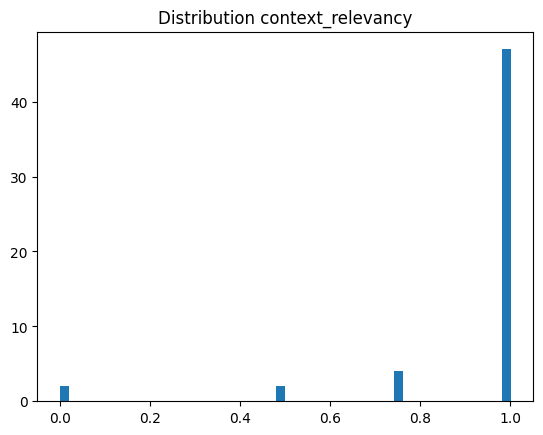

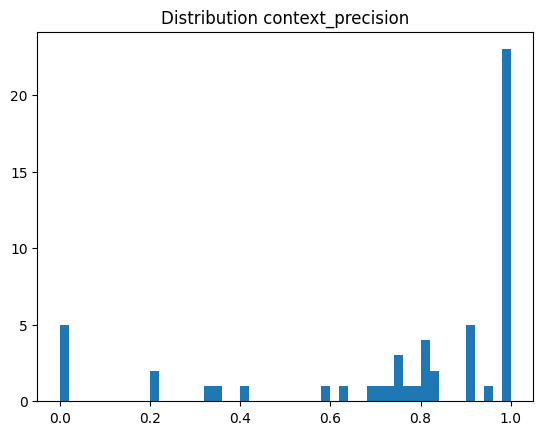

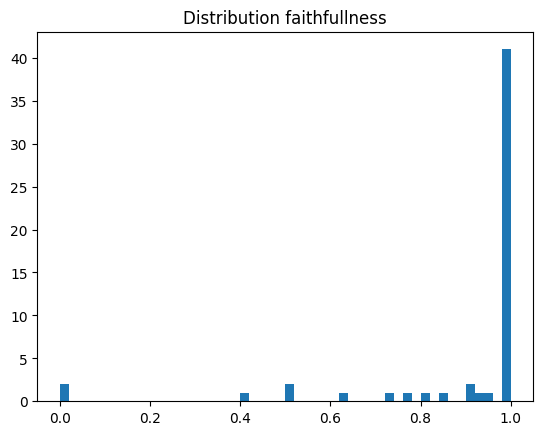

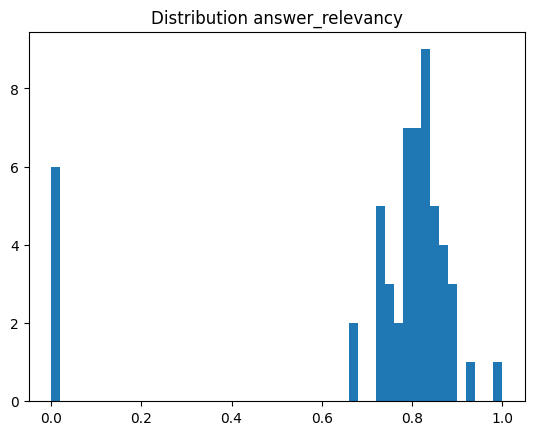

kmeans Context_relevancy : [np.float64(0.25), np.float64(0.625), np.float64(0.875)]
gaussian model context_relevancy: [np.float64(0.25), np.float64(0.625), np.float64(0.875)]

kmeans faithfullness : [np.float64(0.2763), np.float64(0.7675)]
gaussian model faithfullness: [np.float64(0.0048), np.float64(0.9962)]

kmeans answer_relevancy : [np.float64(0.3694), np.float64(0.7899)]
gaussian model answer_relevancy: [np.float64(0.0137), np.float64(0.7883)]

kmeans context_precision : [np.float64(0.1508), np.float64(0.5273), np.float64(0.8685)]
gaussian model context_precision: [np.float64(0.0046), np.float64(0.5151), np.float64(0.9963)]
 
finaux Context_relevancy: [np.float64(0.25), np.float64(0.625), np.float64(0.875)]
finaux Faithfullness: [np.float64(0.1406), np.float64(0.8818)]
finaux Answer_relevancy: [np.float64(0.1916), np.float64(0.7891)]
finaux Context_precision: [np.float64(0.0777), np.float64(0.5212), np.float64(0.9324)]


In [ ]:
def evaluate_clustering(scores, K_values=[3,4,5,6]):
    results = []

    X = np.array(scores).reshape(-1, 1)

    for K in K_values:
        # K-Means
        km = KMeans(n_clusters=K, n_init="auto")
        km_labels = km.fit_predict(X)
        km_sil = silhouette_score(X, km_labels)

        # GMM
        gmm = GaussianMixture(n_components=K)
        gmm_labels = gmm.fit_predict(X)
        gmm_sil = silhouette_score(X, gmm_labels)

        results.append({
            "K": K,
            "kmeans_silhouette": km_sil,
            "gmm_silhouette": gmm_sil,
            "kmeans_model": km,
            "gmm_model": gmm
        })

    return results

# Faithfullness K=6 à les meilleurs performances pour les 2 modèles
# Answer_relevancy K=6 à les meilleurs performances pour les 2 modèles
# Context_precision K=6 à les meilleurs performances pour les 2 modèles
# Context_relevancy K=6 à les meilleurs performances pour les 2 modèles

context_relevancy=2*df["retrieval_score"]-df["context_precision"]

#print(evaluate_clustering(context_relevancy))
X_cr = np.array(context_relevancy).reshape(-1, 1)
X_f = np.array(df["faithfulness"]).reshape(-1, 1)
X_ar = np.array(df["answer_relevancy"]).reshape(-1, 1)
X_cp = np.array(df["context_precision"]).reshape(-1, 1)

# K-Means et GMM pour context_relevancy

kmeans_model_cr= KMeans(n_clusters=4, n_init="auto")
kmeans_model_cr=kmeans_model_cr.fit(X_cr)

gmm_model_cr = GaussianMixture(n_components=4)
gmm_model_cr=gmm_model_cr.fit(X_cr)

# K-Means et GMM pour faithfulness

kmeans_model_f= KMeans(n_clusters=3, n_init="auto")
kmeans_model_f=kmeans_model_f.fit(X_f)

gmm_model_f = GaussianMixture(n_components=3)
gmm_model_f=gmm_model_f.fit(X_f)

# K-Means et GMM pour answer_relevancy

kmeans_model_ar= KMeans(n_clusters=3, n_init="auto")
kmeans_model_ar=kmeans_model_ar.fit(X_ar)

gmm_model_ar = GaussianMixture(n_components=3)
gmm_model_ar=gmm_model_ar.fit(X_ar)

# K-Means et GMM pour context_precision

kmeans_model_cp= KMeans(n_clusters=4, n_init="auto")
kmeans_model_cp=kmeans_model_cp.fit(X_cp)

gmm_model_cp = GaussianMixture(n_components=4)
gmm_model_cp=gmm_model_cp.fit(X_cp)


inertias_cr = {}
inertias_f = {}
inertias_ar = {}
inertias_cp = {}
for k in range(2, 10):
    kmeans_cr = KMeans(n_clusters=k).fit(X_cr)
    kmeans_f = KMeans(n_clusters=k).fit(X_f)
    kmeans_ar = KMeans(n_clusters=k).fit(X_ar)
    kmeans_cp = KMeans(n_clusters=k).fit(X_cp)
    inertias_cr[k] = kmeans_cr.inertia_
    inertias_f[k] = kmeans_f.inertia_
    inertias_ar[k] = kmeans_ar.inertia_
    inertias_cp[k] = kmeans_cp.inertia_

# plt.plot(list(inertias_cr.keys()), list(inertias_cr.values()), marker='o')
# plt.xlabel('Nombre de clusters (K)')
# plt.ylabel('Inertie')
# plt.title('Méthode du coude pour K-Means (context_relevancy)')
# plt.xticks(range(2, 10))
# plt.grid()
# plt.show()

# plt.plot(list(inertias_f.keys()), list(inertias_f.values()), marker='o')
# plt.xlabel('Nombre de clusters (K)')
# plt.ylabel('Inertie')
# plt.title('Méthode du coude pour K-Means (faithfulness)')
# plt.xticks(range(2, 10))
# plt.grid()
# plt.show()

# plt.plot(list(inertias_ar.keys()), list(inertias_ar.values()), marker='o')
# plt.xlabel('Nombre de clusters (K)')
# plt.ylabel('Inertie')
# plt.title('Méthode du coude pour K-Means (answer_relevancy)')
# plt.xticks(range(2, 10))
# plt.grid()
# plt.show() 

# plt.plot(list(inertias_cp.keys()), list(inertias_cp.values()), marker='o')
# plt.xlabel('Nombre de clusters (K)')
# plt.ylabel('Inertie')
# plt.title('Méthode du coude pour K-Means (context_precision)')
# plt.xticks(range(2, 10))
# plt.grid()
# plt.show()


# bics_cr = {}
# bics_f = {}
# bics_ar = {}
# bics_cp = {}
# for k in range(1, 10):
#     gmm_cr = GaussianMixture(n_components=k).fit(X_cr)
#     gmm_f = GaussianMixture(n_components=k).fit(X_f)
#     gmm_ar = GaussianMixture(n_components=k).fit(X_ar)
#     gmm_cp = GaussianMixture(n_components=k).fit(X_cp)
#     bics_cr[k] = gmm_cr.bic(X_cr)
#     bics_f[k] = gmm_f.bic(X_f)
#     bics_ar[k] = gmm_ar.bic(X_ar)
#     bics_cp[k] = gmm_cp.bic(X_cp)

# plt.plot(list(bics_cr.keys()), list(bics_cr.values()), marker='o')
# plt.xlabel('Nombre de clusters (K)')
# plt.ylabel('BIC')
# plt.title('BIC pour GMM (context_relevancy)')
# plt.xticks(range(1, 10))
# plt.grid()
# plt.show()

# plt.plot(list(bics_f.keys()), list(bics_f.values()), marker='o')
# plt.xlabel('Nombre de clusters (K)')
# plt.ylabel('BIC')
# plt.title('BIC pour GMM (faithfulness)')
# plt.xticks(range(1, 10))
# plt.grid()
# plt.show()

# plt.plot(list(bics_ar.keys()), list(bics_ar.values()), marker='o')
# plt.xlabel('Nombre de clusters (K)')
# plt.ylabel('BIC')
# plt.title('BIC pour GMM (answer_relevancy)')
# plt.xticks(range(1, 10))
# plt.grid()
# plt.show()

# plt.plot(list(bics_cp.keys()), list(bics_cp.values()), marker='o')
# plt.xlabel('Nombre de clusters (K)')
# plt.ylabel('BIC')
# plt.title('BIC pour GMM (context_precision)')
# plt.xticks(range(1, 10))
# plt.grid()
# plt.show()

plt.hist(context_relevancy, bins=50)
plt.title("Distribution context_relevancy")
plt.show()

plt.hist(df["context_precision"], bins =50)
plt.title("Distribution context_precision")
plt.show()

plt.hist(df["faithfulness"], bins=50)
plt.title("Distribution faithfulness")
plt.show()

plt.hist(df["answer_relevancy"], bins=50)
plt.title("Distribution answer_relevancy")
plt.show()

def kmeans_seuils(model):
    centers = np.sort(model.cluster_centers_.flatten())
    return [round((centers[i] + centers[i+1]) / 2, 4) for i in range(len(centers)-1)]



def gmm_seuils(model):
    means = model.means_.flatten()
    vars_ = model.covariances_.flatten()
    weights = model.weights_.flatten()

    order = np.argsort(means)
    means, vars_, weights = means[order], vars_[order], weights[order]

    seuils = []
    for i in range(len(means)-1):
        m1, m2 = means[i], means[i+1]
        v1, v2 = vars_[i], vars_[i+1]
        w1, w2 = weights[i], weights[i+1]
        if abs(v1 - v2) < 1e-6:
            seuils.append(round( (m1 + m2) / 2, 4))
            continue
        # Résolution analytique de l'intersection de deux gaussiennes
        a = 1/(2*v1) - 1/(2*v2)
        b = m2/v2 - m1/v1
        c = (m1**2)/(2*v1) - (m2**2)/(2*v2) + np.log((w2*np.sqrt(v1))/(w1*np.sqrt(v2)))
        if b**2 - 4*a*c < 0:
            seuils.append(round( (m1 + m2) / 2, 4))
            continue

        x = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
        seuils.append(round(x, 4))

    return seuils
print(f"kmeans Context_relevancy : {kmeans_seuils(kmeans_model_cr)}")
print(f"gaussian model context_relevancy: {gmm_seuils(gmm_model_cr)}\n")

print(f"kmeans faithfulness : {kmeans_seuils(kmeans_model_f)}")
print(f"gaussian model faithfulness: {gmm_seuils(gmm_model_f)}\n")

print(f"kmeans answer_relevancy : {kmeans_seuils(kmeans_model_ar)}")
print(f"gaussian model answer_relevancy: {gmm_seuils(gmm_model_ar)}\n")

print(f"kmeans context_precision : {kmeans_seuils(kmeans_model_cp)}")
print(f"gaussian model context_precision: {gmm_seuils(gmm_model_cp)}\n ")

final_thresholds_cr = [round((km + gm) / 2, 4) for km, gm in zip(kmeans_seuils(kmeans_model_cr), gmm_seuils(gmm_model_cr))]
final_thresholds_f = [round((km + gm) / 2, 4) for km, gm in zip(kmeans_seuils(kmeans_model_f), gmm_seuils(gmm_model_f))]
final_thresholds_ar = [round((km + gm) / 2, 4) for km, gm in zip(kmeans_seuils(kmeans_model_ar), gmm_seuils(gmm_model_ar))]
final_thresholds_cp = [round((km + gm) / 2, 4) for km, gm in zip(kmeans_seuils(kmeans_model_cp), gmm_seuils(gmm_model_cp))]

print(f"finaux Context_relevancy: {final_thresholds_cr}")
print(f"finaux Faithfulness: {final_thresholds_f}")
print(f"finaux Answer_relevancy: {final_thresholds_ar}")
print(f"finaux Context_precision: {final_thresholds_cp}")

# Faithfulness : [0.1406, 0.8818]

# Answer_relevancy : [0.1916, 0.7891]

# Context_precision : [0.0777,0.5212, 0.9324]

#Context_relevancy : [0.25, 0.625, 0.875]